In [2]:
import sys
sys.path.append("../src/")
%load_ext autoreload
%autoreload 2

In [3]:
from generators.toy_problem_to_json import toy_problem_to_json # type: ignore[reportMissingImports]
from relaxers.quadratic_model_lin_approx import quadratic_model_lin_approx # type: ignore[reportMissingImports]
from relaxers.quadratic_lin_approx_no_surrogate import quadratic_lin_approx_no_surrogate # type: ignore[reportMissingImports]
from testers.condition_number_lin_program import ( # type: ignore[reportMissingImports]
    condition_number,
    condition_number_no_bounds,
    condition_number_nes_basic
)
import matplotlib.pyplot as plt
import numpy as np

true_false = (True, False)

This notebook is for experimenting on with linear approximations to the toy problem or the GasNet-11 problem.

You can download the relevant GasNet-11 files from Sergey's emails.

Some conclusions:
- The condition number is stable with the bound constraints for the toy problem but goes to infinity without them (is there an eigenvalue of 0?)
- The condition number is a bit higher in general for the real problem but still manageable without the bound constraints.
- Most bound constraint parameters to the linear approximation don't affect the condition number. Some (N, lambda) are hard to check because the toy problem seems to have odd properties compared to the real problem. The condition number is linearly proportional to the number of linear constraints. The effect of if the coefficient is included in the surrogate is large and very different depending on toy vs. real.

In [4]:
# Number of copies of the network in the toy system
N=10

# Whether the production and flow variables have upper bounds
F_UPPER_BOUNDS=True

# Whether the demand constraint is an equality or inequality
DEMAND_INEQUALITY=False

# Capacity / demand parameters
GAMMA=1.0
LAMBD=1.0
EPS=0.1
DELTA=0.1

# Lower bounds and upper bound on pressure
LP=LF=0.0
UP=0.5

# The number of linear constraints to use per quadratic constraint
LIN_CONSTRAINTS = 10

# Whether to do an inner or outer approximation
OUTER_APPROXIMATION = True

# Whether the coefficient is part of the surrogate
COEFFICIENT_SURROGATE = True

# Whether to bound the surrogates with bound constraints.
SURROGATE_BOUND_BELOW = True
SURROGATE_BOUND_ABOVE = True

# Whether to remove division in inner approx
# Generally causes inverse scaling with lin constraints
# Good for toy, bad for real
REMOVE_DIVISION = False

13.25024170169774
14.670290756354309


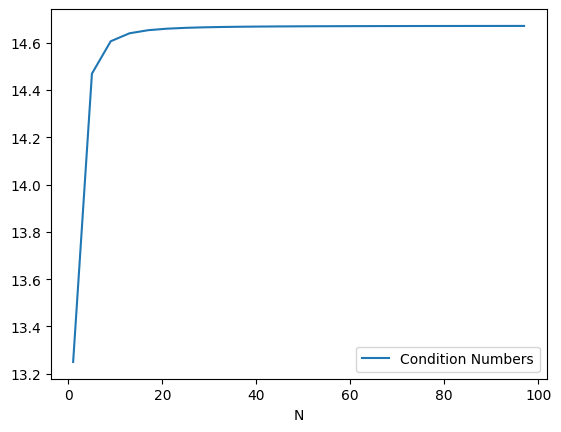

In [4]:
conds = []
n_range = range(1, 101, 4)
# n_range = range(1, 101, 50)
for n in n_range:
    toy_problem_to_json(n, F_UPPER_BOUNDS, DEMAND_INEQUALITY, GAMMA, LAMBD,
                        EPS, DELTA, LP, LF, UP)
    quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, remove_division=REMOVE_DIVISION)
    # quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION)
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("N")
plt.plot(n_range, conds, label="Condition Numbers")
plt.legend()

print(conds[0])
print(conds[-1])

24.3780313424877


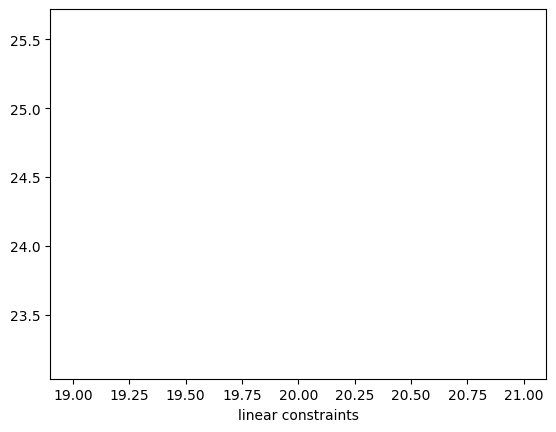

In [7]:
conds = []
lin_cons_range = range(20, 21, 80)
for lin_cons in lin_cons_range:
    toy_problem_to_json(N, F_UPPER_BOUNDS, DEMAND_INEQUALITY, GAMMA, LAMBD,
                        EPS, DELTA, LP, LF, UP)
    quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, remove_division=REMOVE_DIVISION)
    # quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION)
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("linear constraints")
plt.plot(lin_cons_range, conds, label="Condition Numbers")

print(conds[-1])

In [ ]:
for bound_below in true_false:
    for bound_above in true_false:
        toy_problem_to_json(N, F_UPPER_BOUNDS, DEMAND_INEQUALITY, GAMMA, LAMBD,
                            EPS, DELTA, LP, LF, UP)
        quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                    bound_below, bound_above)
        print(f"surrogate bound below: {bound_below}, surrogate bound above: {bound_above}, cond number: {condition_number_nes_basic()}")


surrogate bound below: True, surrogate bound above: True, cond number: 11.921913867380978
surrogate bound below: True, surrogate bound above: False, cond number: 11.921913867380978
surrogate bound below: False, surrogate bound above: True, cond number: 11.921913867380978
surrogate bound below: False, surrogate bound above: False, cond number: 11.921913867380978


In [ ]:
for surrogate_coefficient in true_false:
    toy_problem_to_json(N, F_UPPER_BOUNDS, DEMAND_INEQUALITY, GAMMA, LAMBD,
                        EPS, DELTA, LP, LF, UP)
    quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, surrogate_coefficient,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE)
    print(f"coefficient in surrogate: {surrogate_coefficient}, cond number: {condition_number_nes_basic()}")


coefficient in surrogate: True, cond number: 11.921913867380978
coefficient in surrogate: False, cond number: 9.305190281354804


You are setting remove_division to True for a no-surrogate approximation.
This tends to cause infeasibility or worsen results.
You are setting remove_division to True for a no-surrogate approximation.
This tends to cause infeasibility or worsen results.
You are setting remove_division to True for a no-surrogate approximation.
This tends to cause infeasibility or worsen results.
You are setting remove_division to True for a no-surrogate approximation.
This tends to cause infeasibility or worsen results.
You are setting remove_division to True for a no-surrogate approximation.
This tends to cause infeasibility or worsen results.
You are setting remove_division to True for a no-surrogate approximation.
This tends to cause infeasibility or worsen results.
You are setting remove_division to True for a no-surrogate approximation.
This tends to cause infeasibility or worsen results.
You are setting remove_division to True for a no-surrogate approximation.
This tends to cause infeasibility or 

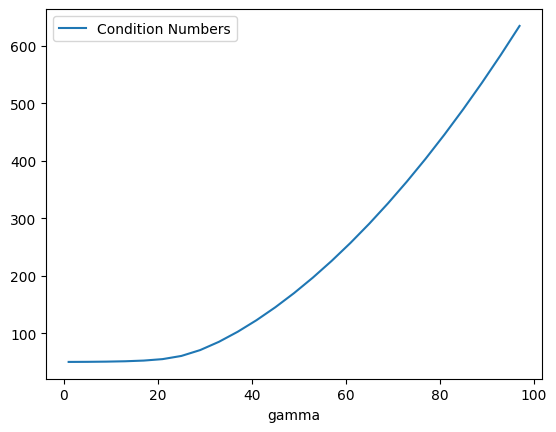

In [30]:
conds = []
gamma_range = range(1, 101, 4)
# gamma_range = range(1, 1001, 40)
for gamma in gamma_range:
    toy_problem_to_json(N, F_UPPER_BOUNDS, DEMAND_INEQUALITY, gamma, LAMBD,
                        EPS, DELTA, LP, LF, UP)
    # quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
    #                             SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, REMOVE_DIVISION)
    quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION, REMOVE_DIVISION)
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("gamma")
plt.plot(gamma_range, conds, label="Condition Numbers")
plt.legend()

You are setting remove_division to True for a no-surrogate approximation.
This tends to cause infeasibility or worsen results.
You are setting remove_division to True for a no-surrogate approximation.
This tends to cause infeasibility or worsen results.
You are setting remove_division to True for a no-surrogate approximation.
This tends to cause infeasibility or worsen results.
You are setting remove_division to True for a no-surrogate approximation.
This tends to cause infeasibility or worsen results.
You are setting remove_division to True for a no-surrogate approximation.
This tends to cause infeasibility or worsen results.
You are setting remove_division to True for a no-surrogate approximation.
This tends to cause infeasibility or worsen results.
You are setting remove_division to True for a no-surrogate approximation.
This tends to cause infeasibility or worsen results.
You are setting remove_division to True for a no-surrogate approximation.
This tends to cause infeasibility or 

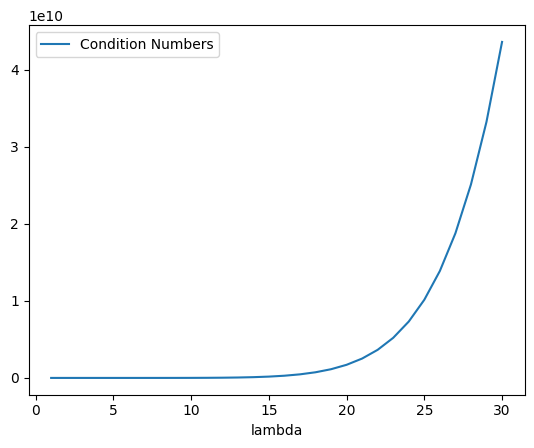

In [ ]:
conds = []
lambd_range = range(1, 31)
# lambd_range = range(1, 101, 4)
for lambd in lambd_range:
    toy_problem_to_json(N, F_UPPER_BOUNDS, DEMAND_INEQUALITY, GAMMA, lambd,
                        EPS, DELTA, LP, LF, UP)
    quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, REMOVE_DIVISION)
    # quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION)
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("lambda")
plt.plot(lambd_range, conds, label="Condition Numbers")
plt.legend()

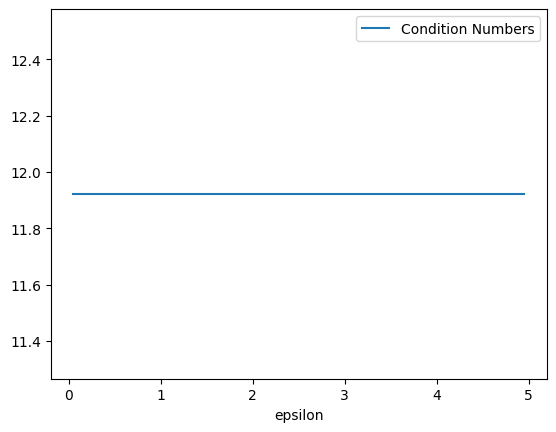

In [ ]:
conds = []
epsilon_range = np.arange(.05, 5, .05)
for epsilon in epsilon_range:
    toy_problem_to_json(N, F_UPPER_BOUNDS, DEMAND_INEQUALITY, GAMMA, LAMBD,
                        epsilon, DELTA, LP, LF, UP)
    quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE)
    # quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION)
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("epsilon")
plt.plot(epsilon_range, conds, label="Condition Numbers")
plt.legend()

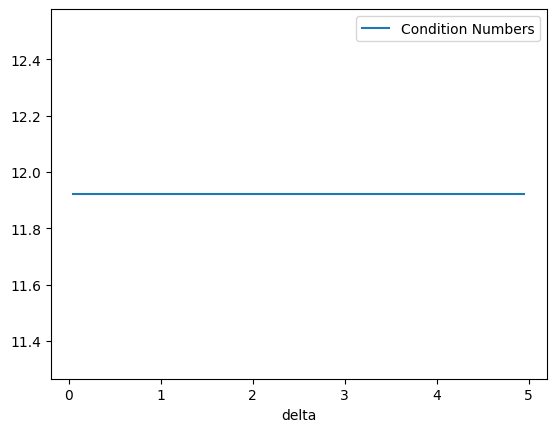

In [ ]:
conds = []
delta_range = np.arange(.05, 5, .05)
for delta in delta_range:
    toy_problem_to_json(N, F_UPPER_BOUNDS, DEMAND_INEQUALITY, GAMMA, LAMBD,
                        EPS, delta, LP, LF, UP)
    quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE)
    # quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION)
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("delta")
plt.plot(delta_range, conds, label="Condition Numbers")
plt.legend()

In [16]:
print(condition_number_nes_basic(bounds=2, f_name="Model11_lp.json"))

4720.915473520315


There are 28 variables, 11 equality constraints, and 26 non-bound inequality constraints
Removed 0 unused variables
G =
[[ 0.          1.         -1.          0.          0.          1.
   0.          0.         -1.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.         -1.          0.          1.          1.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.         -1.         -1.
   0.          0.          0.          1.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0

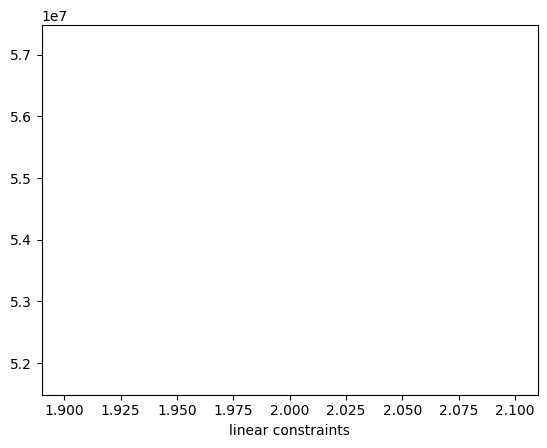

In [29]:
conds = []
# lin_cons_range = range(1, 11)
lin_cons_range = range(2, 101, 4)
# lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    # quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
    #                             SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, remove_division=False,
    #                             endpoints=False, f_name="model11_quad_reform_2.json")
    quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION, remove_division=REMOVE_DIVISION,
                                        endpoints=False, f_name="model11_quad_reform_nofix.json")
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("linear constraints")
plt.plot(lin_cons_range, conds, label="Condition Numbers")

print(conds[-1])
print(conds[0])

In [19]:
quadratic_model_lin_approx(10, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                False, True, remove_division=False,
                                f_name="model11_quad_reform_nofix.json")
condition_number_nes_basic(verbose=False)

np.float64(4774.12156258927)

In [20]:
quadratic_lin_approx_no_surrogate(10, False, remove_division=False,
                                f_name="model11_quad_reform_nofix.json")
condition_number_nes_basic(verbose=False)

np.float64(4524.662190674955)

14.492422290126223
107.59246972265517


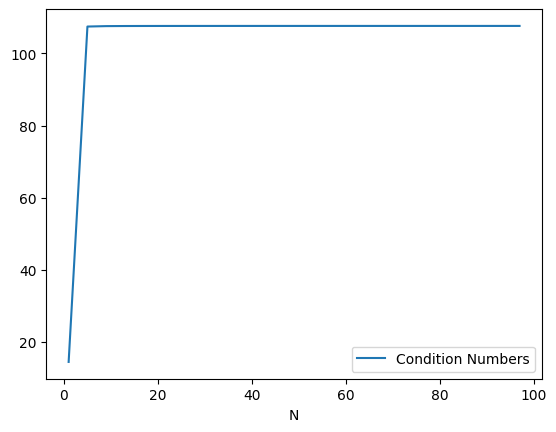

In [45]:
conds = []
n_range = range(1, 101, 4)
# n_range = range(1, 101, 50)
for n in n_range:
    toy_problem_to_json(n, F_UPPER_BOUNDS, DEMAND_INEQUALITY, GAMMA, LAMBD,
                        EPS, DELTA, LP, LF, UP)
    quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, remove_division=False)
    # quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION)
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("N")
plt.plot(n_range, conds, label="Condition Numbers")
plt.legend()

print(conds[0])
print(conds[-1])

# Testing other point distribution functions

In [ ]:
rng = np.random.default_rng()

conds = []
lin_cons_range = range(2, 101, 4)
# lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    toy_problem_to_json(N, F_UPPER_BOUNDS, DEMAND_INEQUALITY, GAMMA, LAMBD,
                        EPS, DELTA, LP, LF, UP)
    quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
                                points_function=rng.uniform)
    # quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION,
    #                                     points_function=rng.uniform)
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("linear constraints")
plt.plot(lin_cons_range, conds, label="Condition Numbers")
print(conds[-1])

47450.903575010285
5768.800542197519


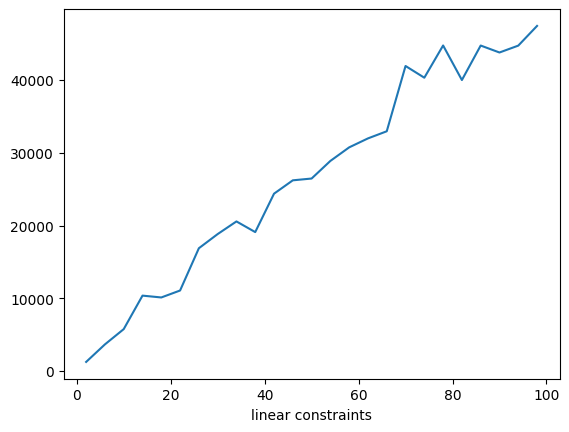

In [8]:
rng = np.random.default_rng()

conds = []
lin_cons_range = range(2, 101, 4)
# lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    # quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
    #                             SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, remove_division=False,
    #                             points_function=rng.uniform, f_name="model11_quad_reform_2.json")
    quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION, remove_division=False,
                                        points_function=rng.uniform, f_name="model11_quad_reform_2.json")
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("linear constraints")
plt.plot(lin_cons_range, conds, label="Condition Numbers")

print(conds[-1])
print(conds[2])

In [ ]:
concat = 1.67

def np_uniform_bunch_low(lower: float, upper: float, num: int):
    return np.linspace(lower, lower + ((upper - lower)/concat), num)

def np_uniform_bunch_high(lower: float, upper: float, num: int):
    return np.linspace(upper - ((upper - lower) / concat), upper, num)

def np_uniform_bunch_middle(lower: float, upper: float, num: int):
    midpoint = (lower + upper) / 2
    return np.linspace(midpoint - ((upper - lower) / (2*concat)), midpoint + ((upper - lower)/(2*concat)), num)

397.4204472497198


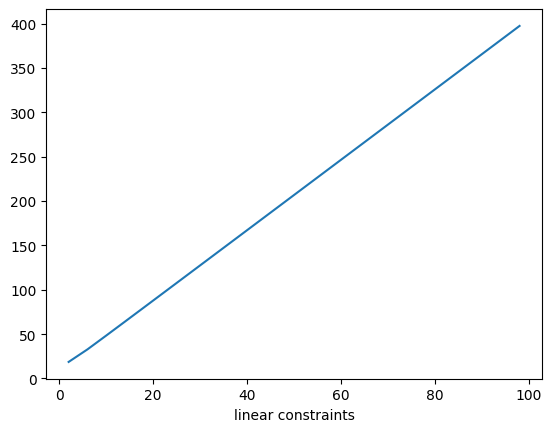

In [24]:
conds = []
lin_cons_range = range(2, 101, 4)
# lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    toy_problem_to_json(N, F_UPPER_BOUNDS, DEMAND_INEQUALITY, GAMMA, LAMBD,
                        EPS, DELTA, LP, LF, UP)
    quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
                                points_function=np_uniform_bunch_low)
    # quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION,
                                        # points_function=np_uniform_bunch_low)
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("linear constraints")
plt.plot(lin_cons_range, conds, label="Condition Numbers")
print(conds[-1])

16108.387760048718
1729.2661006654632


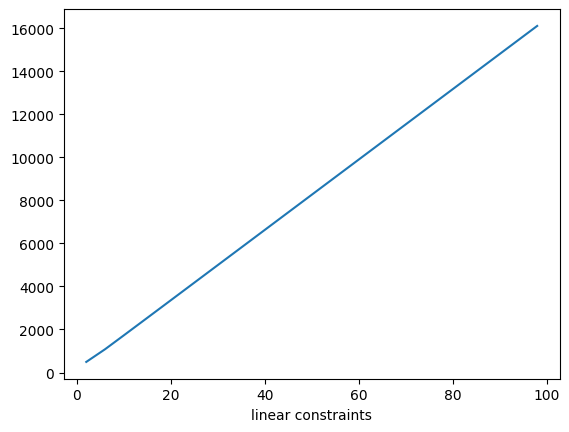

In [28]:
conds = []
lin_cons_range = range(2, 101, 4)
# lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    # quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
    #                             SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, remove_division=False,
    #                             points_function=np_uniform_bunch_low, f_name="model11_quad_reform_2.json")
    quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION, remove_division=False,
                                        points_function=np_uniform_bunch_low, f_name="model11_quad_reform_nofix.json")
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("linear constraints")
plt.plot(lin_cons_range, conds, label="Condition Numbers")

print(conds[-1])
print(conds[2])

1028.5206992184897


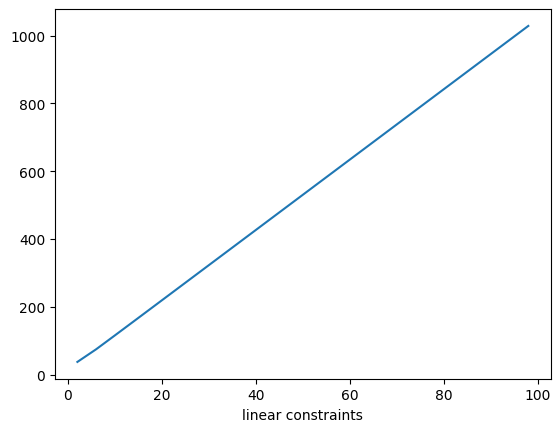

In [31]:
conds = []
lin_cons_range = range(2, 101, 4)
# lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    toy_problem_to_json(N, F_UPPER_BOUNDS, DEMAND_INEQUALITY, GAMMA, LAMBD,
                        EPS, DELTA, LP, LF, UP)
    quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
                                points_function=np_uniform_bunch_high)
    # quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION,
                                        # points_function=np_uniform_bunch_high)
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("linear constraints")
plt.plot(lin_cons_range, conds, label="Condition Numbers")
print(conds[-1])

69398.1601908716
7167.551686073838


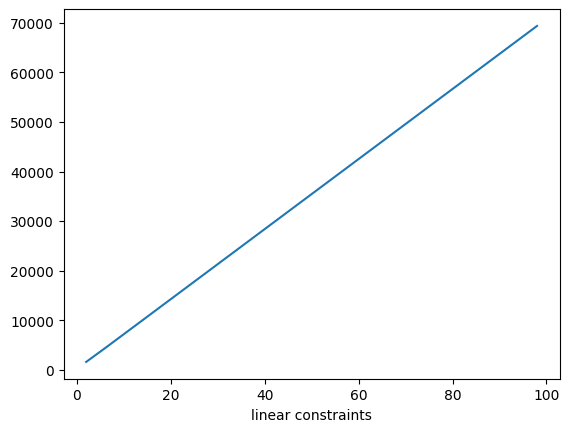

In [30]:
conds = []
lin_cons_range = range(2, 101, 4)
# lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    # quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
    #                             SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, remove_division=False,
    #                             points_function=np_uniform_bunch_high, f_name="model11_quad_reform_2.json")
    quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION, remove_division=False,
                                        points_function=np_uniform_bunch_high, f_name="model11_quad_reform_nofix.json")
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("linear constraints")
plt.plot(lin_cons_range, conds, label="Condition Numbers")

print(conds[-1])
print(conds[2])

In [ ]:
conds = []
lin_cons_range = range(2, 101, 4)
# lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    toy_problem_to_json(N, F_UPPER_BOUNDS, DEMAND_INEQUALITY, GAMMA, LAMBD,
                        EPS, DELTA, LP, LF, UP)
    quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
                                points_function=np_uniform_bunch_middle)
    # quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION,
    #                                     points_function=np_uniform_bunch_middle)
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("linear constraints")
plt.plot(lin_cons_range, conds, label="Condition Numbers")
print(conds[-1])

34880.02374261674
3614.3941949264067


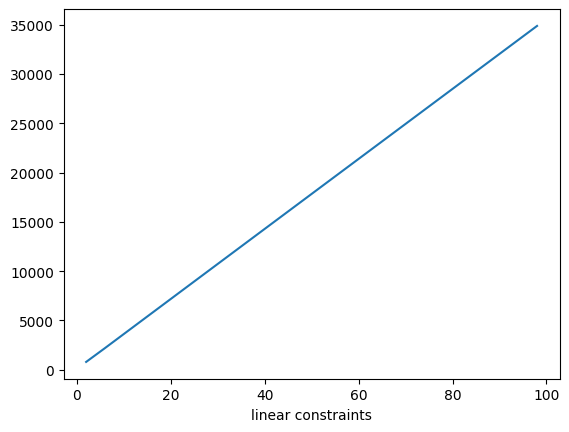

In [13]:
conds = []
lin_cons_range = range(2, 101, 4)
# lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    # quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
    #                             SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, remove_division=False,
    #                             points_function=np_uniform_bunch_middle, f_name="model11_quad_reform_2.json")
    quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION, remove_division=False,
                                        points_function=np_uniform_bunch_middle, f_name="model11_quad_reform_2.json")
    # conds.append(condition_number())
    # conds.append(condition_number_no_bounds())
    conds.append(condition_number_nes_basic())

plt.xlabel("linear constraints")
plt.plot(lin_cons_range, conds, label="Condition Numbers")

print(conds[-1])
print(conds[2])

In [ ]:
points = np.linspace(1.1, 2, 500, endpoint=True)

toy_problem_to_json(N, F_UPPER_BOUNDS, DEMAND_INEQUALITY, GAMMA, LAMBD,
                    EPS, DELTA, LP, LF, UP)

conds = []
for concat in points:
    
    def np_uniform_bunch_low(lower: float, upper: float, num: int):
        return np.linspace(lower, lower + ((upper - lower)/concat), num)

    
    # quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
    #                             SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
    #                             points_function=np_uniform_bunch_middle, remove_division=REMOVE_DIVISION,
    #                             f_name="model11_quad_reform_2.json")
    quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION, remove_division=REMOVE_DIVISION,
                                        f_name="toy.json")
    conds.append(condition_number_nes_basic())

plt.xlabel("concatenation parameter")
plt.plot(points, conds, label="Cond no.")

print(points[np.argmin(np.abs(conds))])

There are 199 variables, 41 equality constraints, and 990 non-bound inequality constraints
Removed 0 unused variables
G =
[[-1.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0. -1.  1.]
 [ 0.  0.  0. ... -1. -1.  0.]]
cond(G) = 2.6774696178092925
2G^TG = 
[[ 2.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  2.  2.  0.]
 [ 0.  0.  0. ...  2.  4. -2.]
 [ 0.  0.  0. ...  0. -2.  4.]]
cond(2G^TG) = inf
A =
[[ 1.          0.          0.         ...  0.          0.
   0.        ]
 [ 1.          0.          0.         ...  0.          0.
   0.        ]
 [ 1.          0.          0.         ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ...  0.          0.
  -3.47832796]
 [ 0.          0.          0.         ...  0.          0.
  -3.97523196]
 [ 0.          0.          0.         ...  0.          0.
  -4.4

[   0.  100.  200.  300.  400.  500.  600.  700.  800.  900. 1100.]
[   0.  100.  200.  300.  400.  500.  600.  700.  800.  900. 1100.]
[   0.  100.  200.  300.  400.  500.  600.  700.  800.  900. 1100.]
[   0.  100.  200.  300.  400.  500.  600.  700.  800.  900. 1100.]
[   0.  100.  200.  300.  400.  500.  600.  700.  800.  900. 1100.]
[   0.  100.  200.  300.  400.  500.  600.  700.  800.  900. 1100.]
[   0.  100.  200.  300.  400.  500.  600.  700.  800.  900. 1100.]
[   0.  100.  200.  300.  400.  500.  600.  700.  800.  900. 1100.]
Made a linear approximation with 93 (non-bound) constraints.
[   0.           99.83630411  199.67260822  299.50891233  399.34521644
  499.18152055  599.01782466  698.85412877  798.69043288  898.526737
 1100.        ]
[   0.           99.83630411  199.67260822  299.50891233  399.34521644
  499.18152055  599.01782466  698.85412877  798.69043288  898.526737
 1100.        ]
[   0.           99.83630411  199.67260822  299.50891233  399.34521644
  499.181520

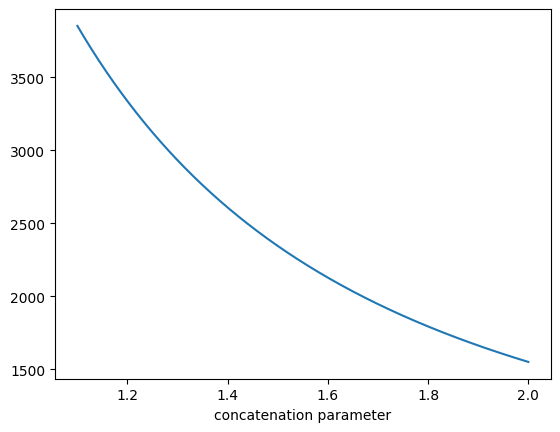

In [35]:
points = np.linspace(1.1, 2, 500, endpoint=True)
LIN_CONSTRAINTS = 10

conds = []
for concat in points:
    
    def np_uniform_bunch_low(lower: float, upper: float, num: int):
        return np.append(np.linspace(lower, lower + ((upper - lower)/concat), num)[0:-1], [upper])

    
    # quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
    #                             SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
    #                             points_function=np_uniform_bunch_middle, remove_division=REMOVE_DIVISION,
    #                             f_name="model11_quad_reform_2.json")
    quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, False, endpoints=True,
                                        points_function=np_uniform_bunch_low, remove_division=REMOVE_DIVISION,
                                        f_name="model11_quad_reform_nofix.json", verbose=True)
    conds.append(condition_number_nes_basic())

plt.xlabel("concatenation parameter")
plt.plot(points, conds, label="Cond no.")

print(points[np.argmin(np.abs(conds))])